# Local Alternative Bars — `plotly.local.alternative_bars`

This notebook shows how to use the `plotly.local.alternative_bars` style to visualise local alternative explanations from `calibrated-explanations`.

## Key interpretation rule

> **Each bar is an independent candidate scenario, not a component of a shared total.**
>
> Alternative 1 says: "if `age <= 42`, the model would predict X."
> Alternative 2 says: "if `income > 50 000`, the model would predict Y."
> These are separate hypothetical scenarios. Their bar values must not be summed.

The x-axis shows the **absolute predicted output** under each scenario. The shaded background band marks the base prediction interval.

## Supported plugin options

| Option | Default | Effect |
|---|---|---|
| `filter_top=N` | `None` | Keep only the top N alternatives |
| `hover_detail="compact"/"full"` | `"compact"` | Amount of info in hover card |

> **Note:** Ranking/sorting is controlled by CE's own `rnk_metric` parameter (default `"ensured"` for alternatives), applied before the plugin receives the rules.

In [1]:
# import subprocess
# import sys
# from pathlib import Path

# package_dir = Path.cwd().resolve()
# if package_dir.name == 'examples':
#     package_dir = package_dir.parent
# else:
#     repo_candidate = Path('packages/visualization/calibrated-explanations-visualization-plotly').resolve()
#     if repo_candidate.exists():
#         package_dir = repo_candidate

# subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-e', str(package_dir)])
# subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'plotly>=5.18'])

# import importlib
# import ce_visualization_plotly
# import ce_visualization_plotly.plugin as plotly_plugin

# importlib.reload(plotly_plugin)
# plotly_plugin.register_plotly_visualization_components()

In [ ]:
import numpy as np
from sklearn.datasets import make_classification, make_regression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split

from calibrated_explanations import WrapCalibratedExplainer
import ce_visualization_plotly.plugin  # noqa: F401 — registers Plotly styles and bridges

## 1 — Probabilistic classification

In [3]:
X, y = make_classification(
    n_samples=1000, n_features=6, n_informative=4,
    n_redundant=0, random_state=42,
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y,
)
X_proper, X_cal, y_proper, y_cal = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train,
)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_proper, y_proper)

explainer = WrapCalibratedExplainer(model).calibrate(X_cal, y_cal)
alternatives = explainer.explore_alternatives(X_test[:3])

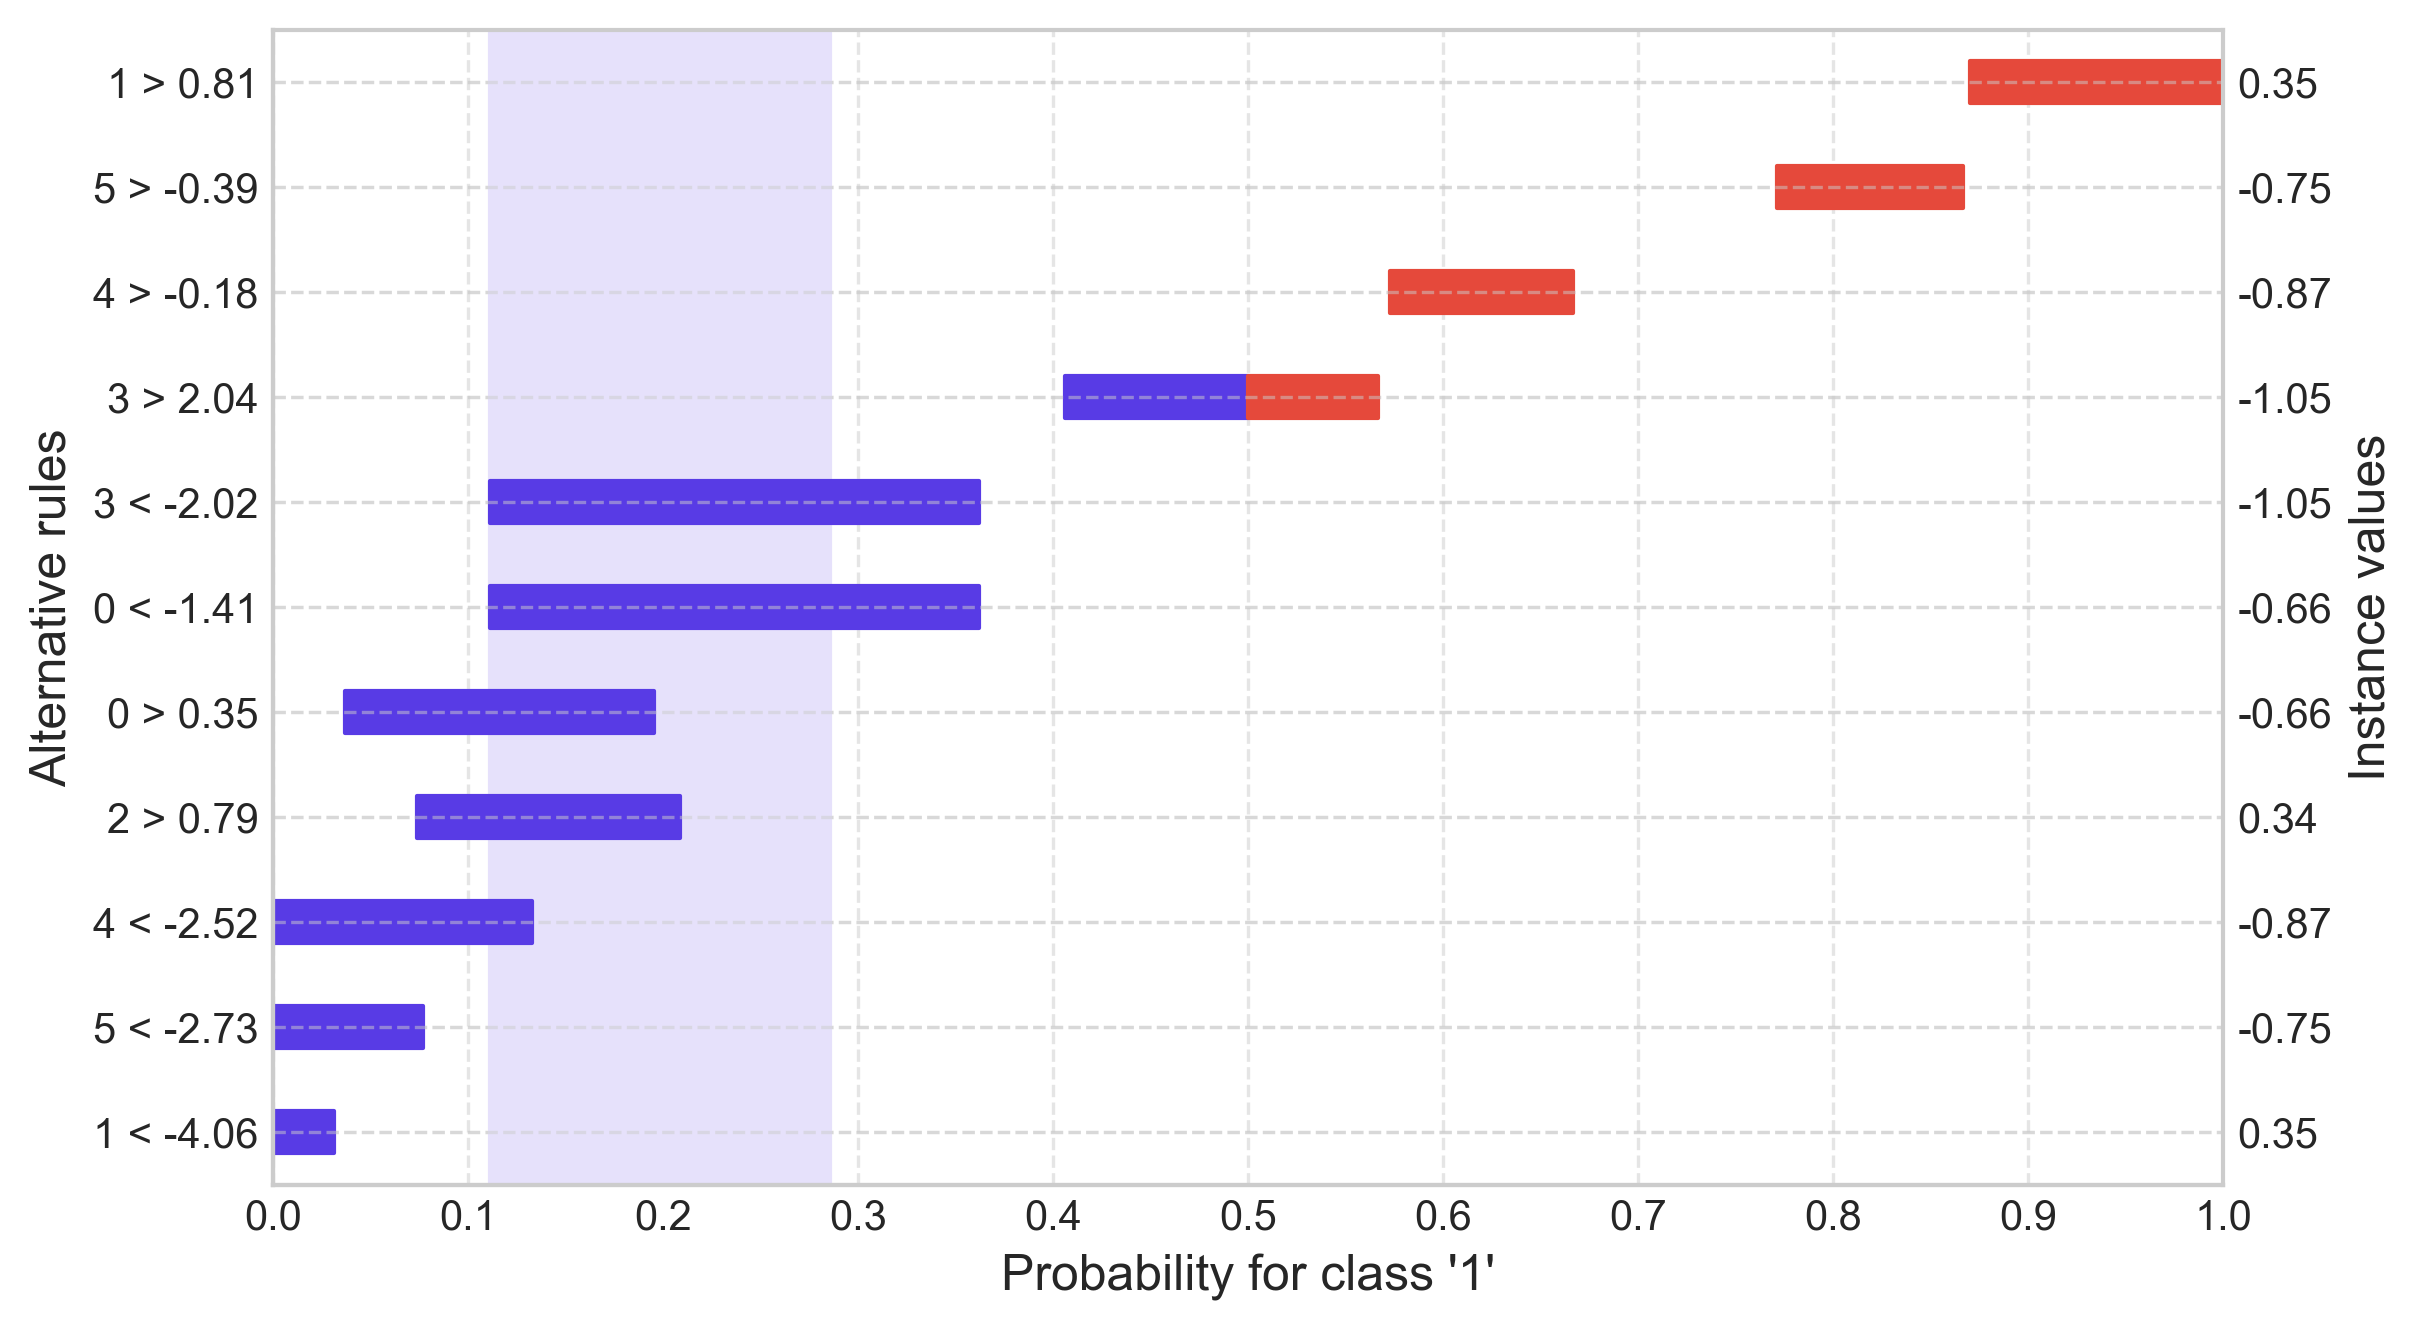

In [ ]:
# Default view: absolute prediction per scenario, uncertainty intervals shown
alternatives[0].plot(
    style="plotly.local.alternative_bars",
    show=True,
)

### Conjunctive alternatives

`add_conjunctions()` enriches the rule set with multi-feature combinations. Use `filter_top` to keep the chart readable.

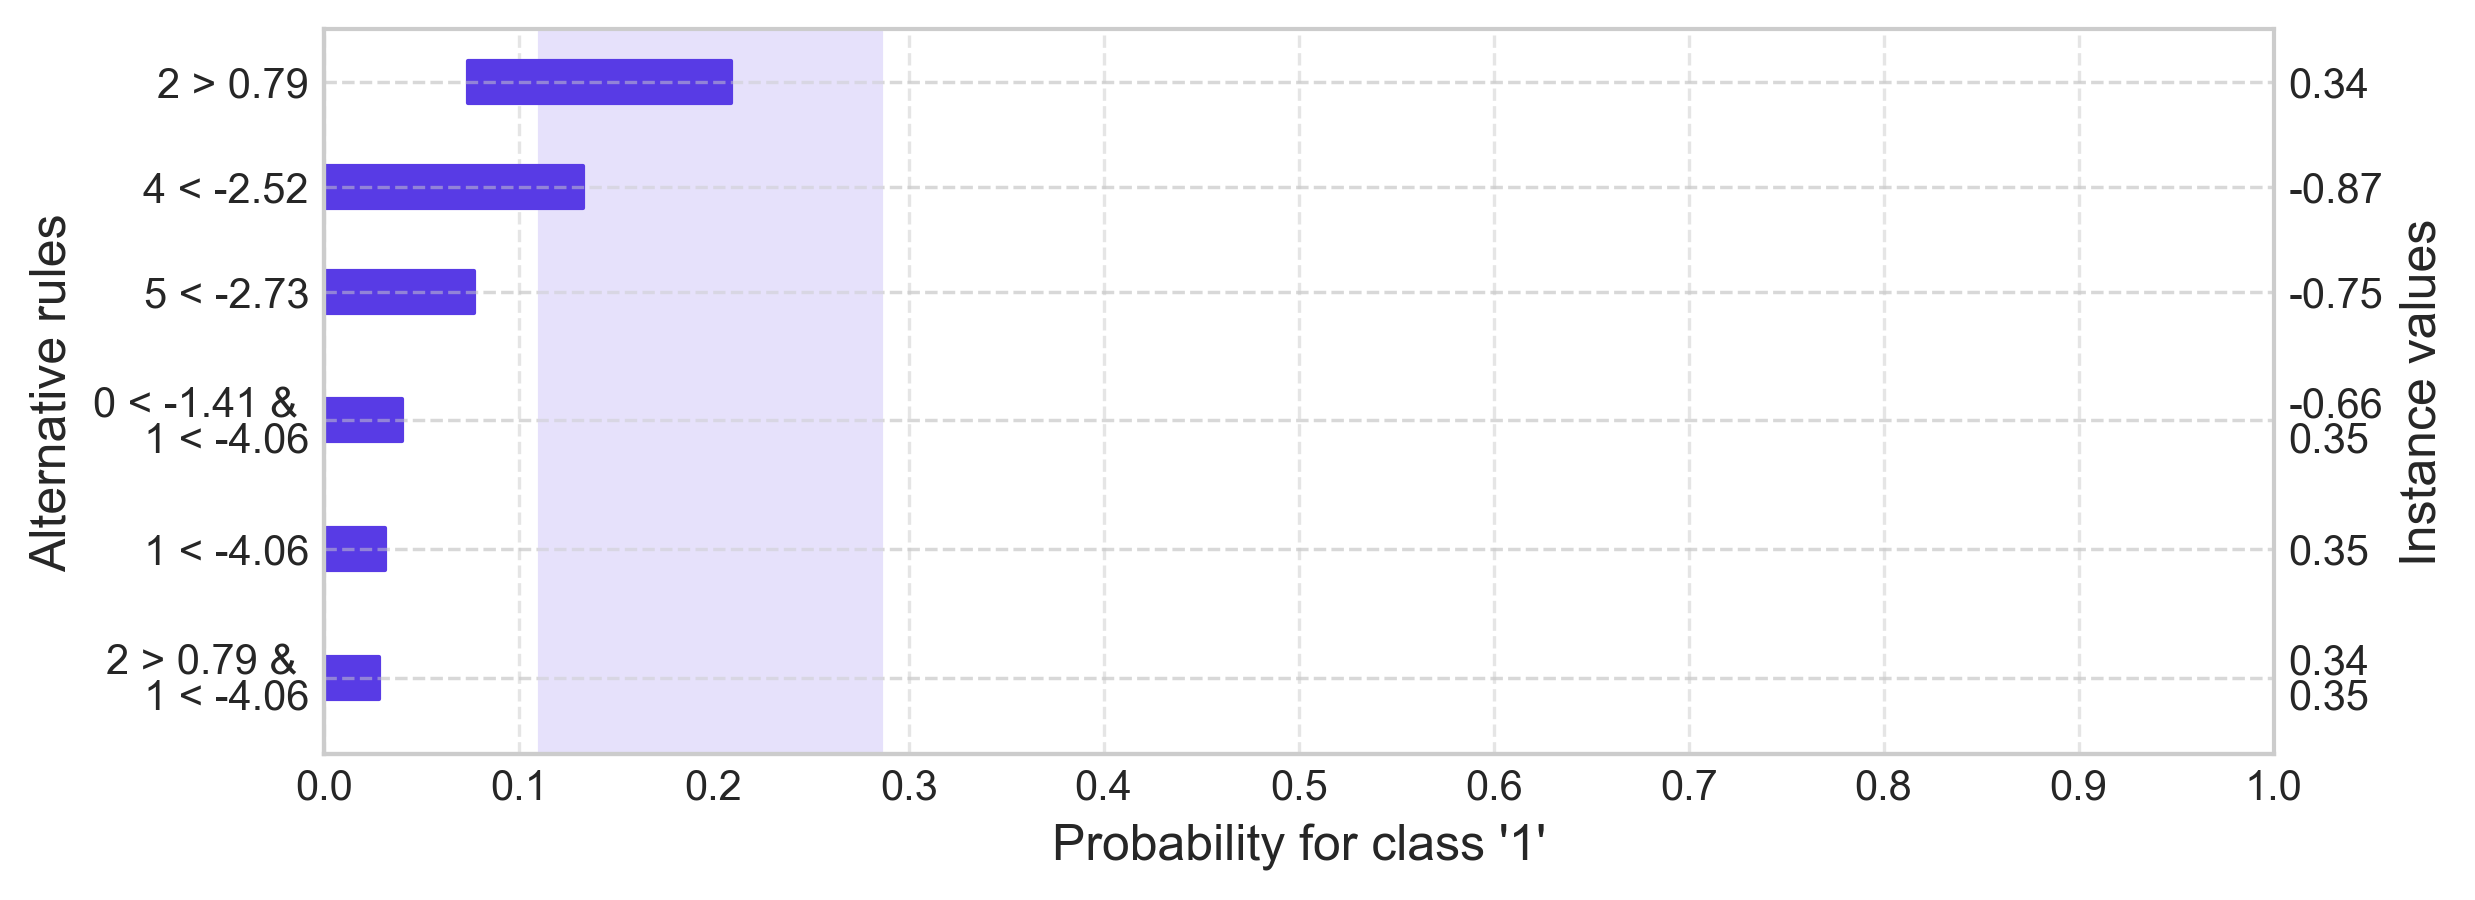

In [5]:
alternatives.add_conjunctions(max_rule_size=2)

alternatives[0].plot(
    style="plotly.local.alternative_bars",
    show=True,
    filter_top=6,
);

### Filtering — top N alternatives

`filter_top` limits the chart to the N alternatives returned first by CE's ranker (default ranking metric: `rnk_metric="ensured"`).

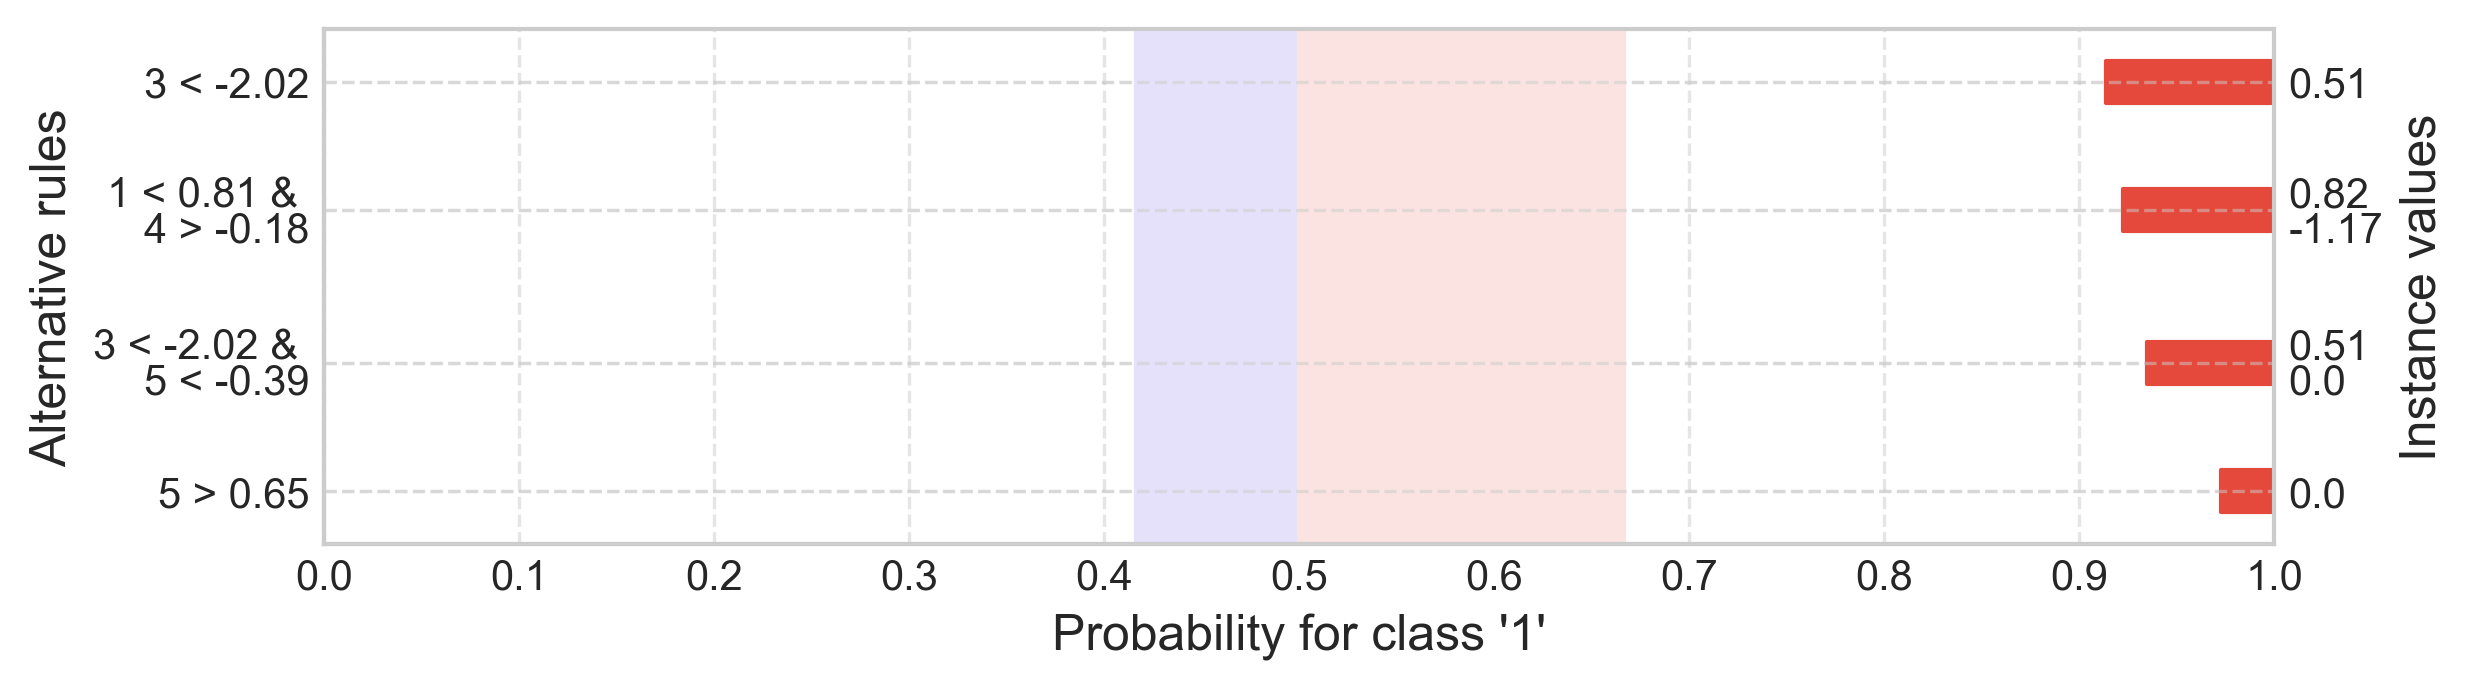

In [6]:
alternatives[1].plot(
    style="plotly.local.alternative_bars",
    show=True,
    filter_top=4,
);

### Hover detail

`hover_detail="full"` adds feature names, current values, and the full prediction interval to each hover card. The default `"compact"` shows only the rule text and predicted probability.

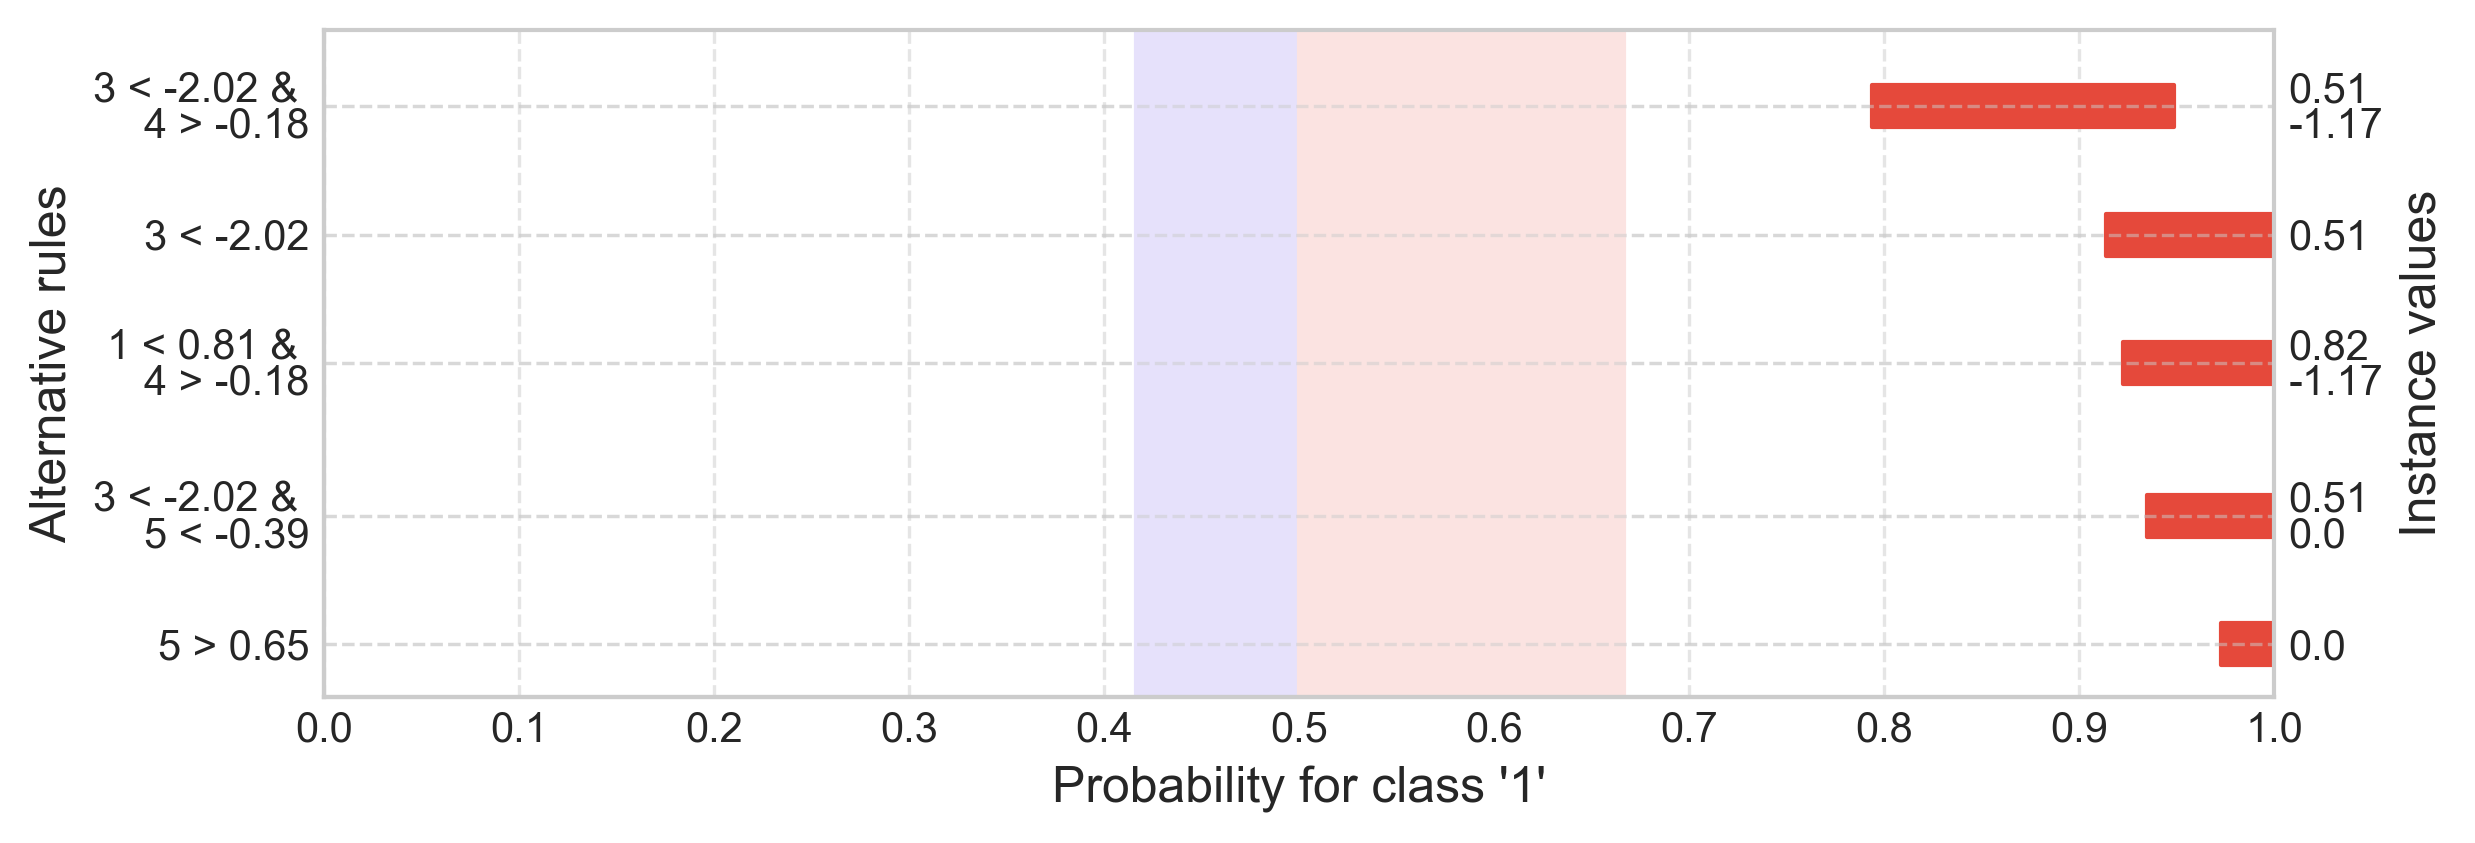

In [7]:
alternatives[1].plot(
    style="plotly.local.alternative_bars",
    show=True,
    filter_top=5,
    hover_detail="full",
);

### Uncertainty intervals

By default, `show_uncertainty=True` draws a horizontal interval bar from `predict_low` to `predict_high` on each row, with a marker at the point prediction. Set `show_uncertainty=False` to show only the prediction marker.

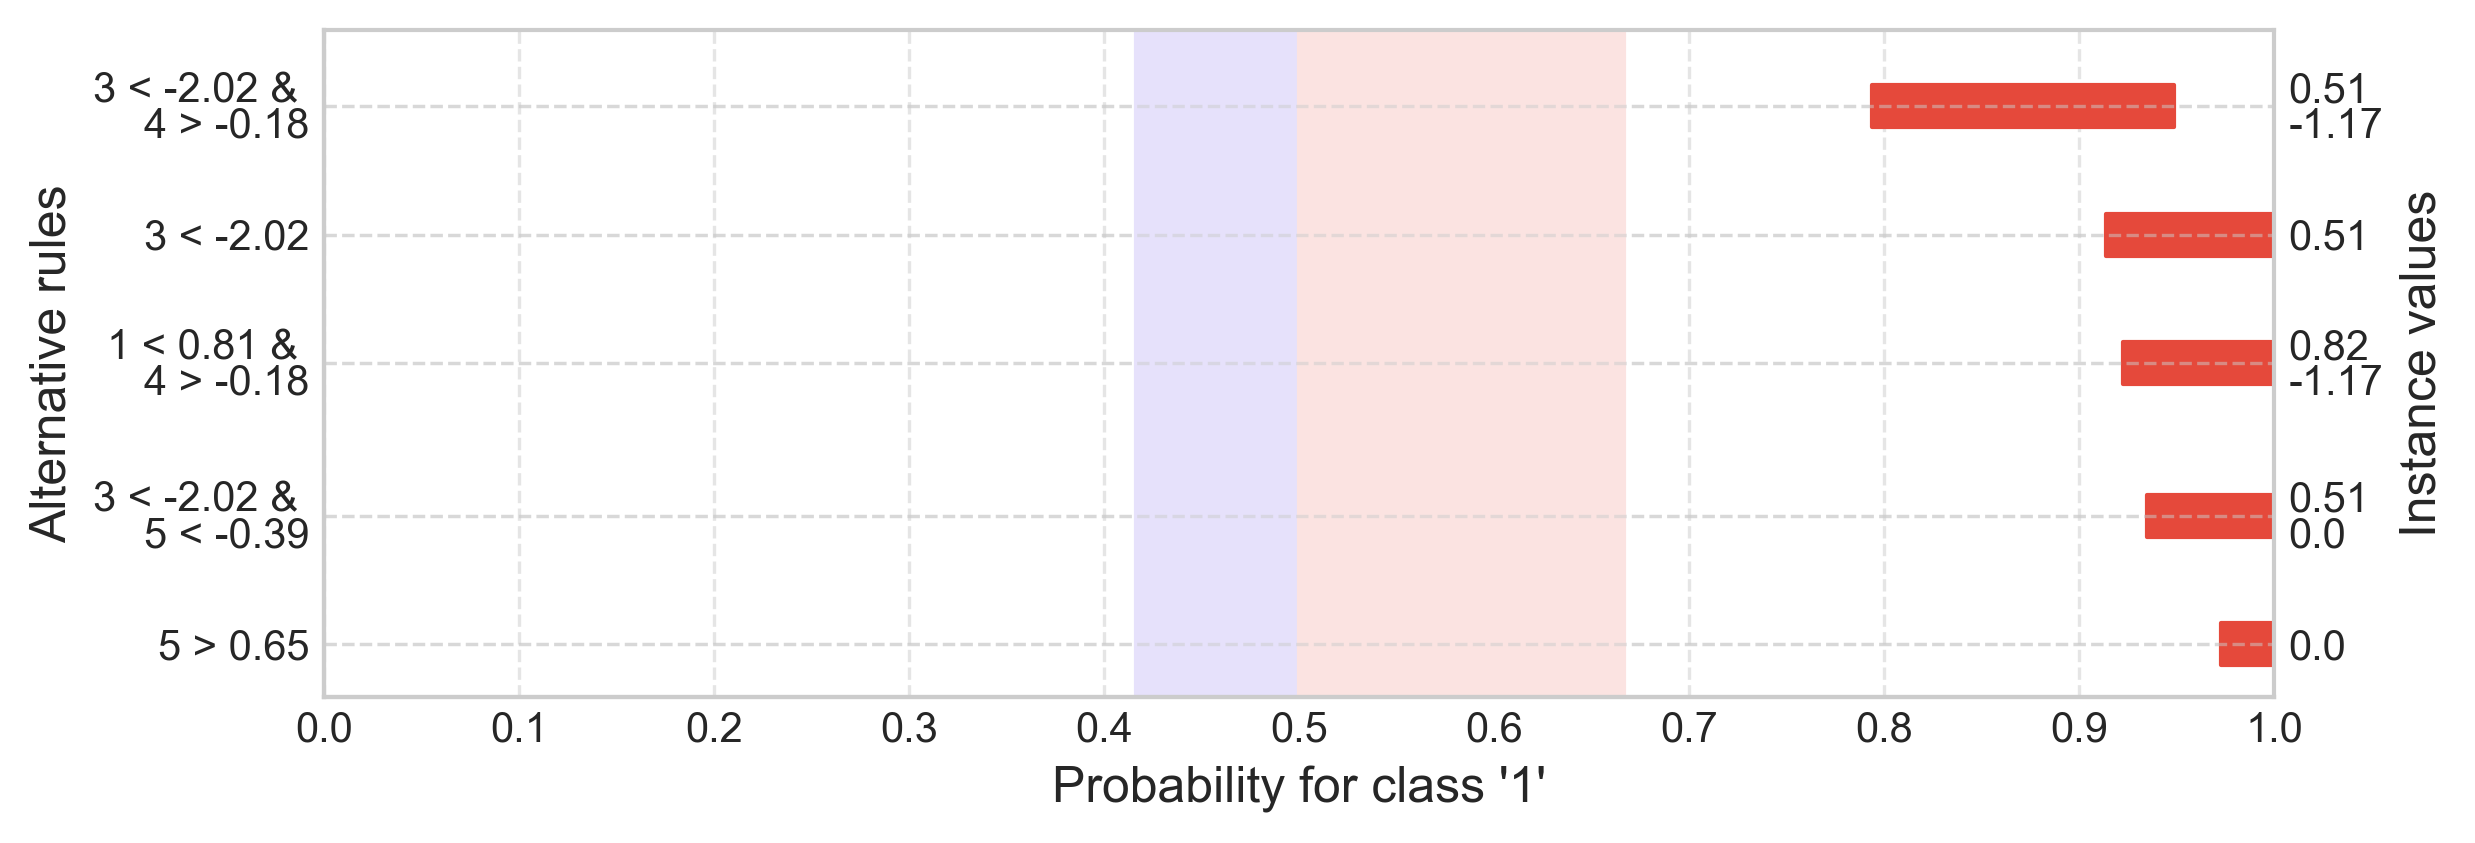

In [8]:
alternatives[1].plot(
    style="plotly.local.alternative_bars",
    show=True,
    filter_top=5,
    show_uncertainty=False,
);

### HTML export

In [9]:
result = alternatives[0].plot(
    style="plotly.local.alternative_bars",
    filter_top=8,
    show=False,
)
result.figure.write_html("alternative_bars_classification.html")

AttributeError: 'NoneType' object has no attribute 'figure'

## 2 — Colour interpretation

Bar and interval colours reflect the **predicted class direction** for each alternative scenario:

| Colour | Meaning |
|--------|----------|
| Blue | Predicted probability ≥ 0.5 (positive-class leaning) |
| Red | Predicted probability < 0.5 (negative-class leaning) |
| Red-orange | Regression — no class distinction |

The shaded background band spans the **base prediction interval** (the current instance’s calibrated `predict_low` → `predict_high`). The left half of the band (< 0.5) is tinted red; the right half (> 0.5) is tinted blue. A dotted line marks the decision pivot (0.5 for binary classification).

Right-side labels show the **current feature value** for the feature changed by each rule.

## 3 — Regression example

In [ ]:
X_reg, y_reg = make_regression(
    n_samples=800, n_features=6, n_informative=5,
    noise=10.0, random_state=11,
)
X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.15, random_state=11)
X_pr, X_cl, y_pr, y_cl = train_test_split(X_tr, y_tr, test_size=0.2, random_state=11)

reg_model = RandomForestRegressor(n_estimators=100, random_state=11)
reg_model.fit(X_pr, y_pr)

reg_explainer = WrapCalibratedExplainer(reg_model).calibrate(X_cl, y_cl)
reg_alternatives = reg_explainer.explore_alternatives(
    X_te[:3], low_high_percentiles=(10, 90),
)

In [ ]:
reg_alternatives[0].plot(
    style="plotly.local.alternative_bars",
    show=True,
    filter_top=6,
);